# Neural Networks
### This stage will work through the process of training my neural network

### Import and Setup

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import torch
from torch import nn
from torch import optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn.functional as F
import torch.nn.utils as utils

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [92]:
nn_feature_set = [
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'is_weekend', 'is_am_rush_hour', 'is_pm_rush_hour', 
    'latitude', 'longitude', 'dist_to_union_km', 
    'cluster_east_end', 'cluster_west_end', 'cluster_uptown', 'cluster_scarborough',
    'temp_c', 'precip_mm', 'rel_humidity_pct', 'visibility_km',
    'capacity', 'is_charging_station', 
    'bus', 'subway', 'streetcar', 'train',
    'restaurants_bars', 'education', 'park', 'tourism', 'office', 'commercial', 'healthcare'
]


In [93]:
raw_train_sample = pd.read_csv('train_sample_2.csv')
raw_train = pd.read_csv('train_2.csv')
raw_val = pd.read_csv('val_2.csv')
raw_test = pd.read_csv('test_2.csv')

print(f'Train Sample Shape: {raw_train_sample.shape}')
print(f'Train Full Shape: {raw_train.shape}')
print(f'Validation Shape: {raw_val.shape}')
print(f'Test Shape: {raw_test.shape}')

Train Sample Shape: (1086590, 49)
Train Full Shape: (10865904, 49)
Validation Shape: (1381274, 49)
Test Shape: (1338746, 49)


### Separate features and targets

In [94]:
# Separate features and target
X_train_sample_nn = raw_train_sample[nn_feature_set]
y_train_sample_nn = raw_train_sample['trips_started']

X_train_nn = raw_train[nn_feature_set]
y_train_nn = raw_train['trips_started']

X_val_nn = raw_val[nn_feature_set]
y_val_nn = raw_val['trips_started']

X_test_nn = raw_test[nn_feature_set]
y_test_nn = raw_test['trips_started']

In [95]:
# Prepare initial baby sample for quick tests
baby_train_sample = raw_train_sample.sample(n=4, random_state=seed).reset_index(drop=True)  # Smaller sample for quick tests

X_baby_train_sample = baby_train_sample[nn_feature_set]
y_baby_train_sample = baby_train_sample['trips_started']

### Scaling

In [96]:
# Define numeric columns to scale (exclude binary features)
numeric_cols = [
    # Cyclic Time
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    # Space & Density
    'latitude', 'longitude', 'dist_to_union_km', 
    # Weather
    'temp_c', 'precip_mm', 'rel_humidity_pct', 'visibility_km',
    # Station characteristics
    'capacity',
    # POI Counts
    'bus', 'subway', 'streetcar', 'train',
    'restaurants_bars', 'education', 'park', 'tourism', 'office', 'commercial', 'healthcare'
]

# Binary/categorical features (don't scale these)
binary_cols = [
    'is_weekend', 'is_am_rush_hour', 'is_pm_rush_hour',
    'cluster_east_end', 'cluster_west_end', 'cluster_uptown', 'cluster_scarborough',
    'is_charging_station'
]

print(f"\nFeatures to scale: {len(numeric_cols)}")
print(f"Binary features (keep as-is): {len(binary_cols)}")



Features to scale: 25
Binary features (keep as-is): 8


In [97]:
print("\n--- Fitting scaler on FULL training set ---")
scaler_nn = StandardScaler()
scaler_nn.fit(X_train_nn[numeric_cols])

# Now scale all datasets using the same scaler
X_train_sample_nn_scaled = X_train_sample_nn.copy()
X_train_nn_scaled = X_train_nn.copy()
X_val_nn_scaled = X_val_nn.copy()
X_test_nn_scaled = X_test_nn.copy()

X_train_sample_nn_scaled[numeric_cols] = scaler_nn.transform(X_train_sample_nn[numeric_cols])
X_train_nn_scaled[numeric_cols] = scaler_nn.transform(X_train_nn[numeric_cols])
X_val_nn_scaled[numeric_cols] = scaler_nn.transform(X_val_nn[numeric_cols])
X_test_nn_scaled[numeric_cols] = scaler_nn.transform(X_test_nn[numeric_cols])

# Verification
print(f"\n=== Scaled Data Ready ===")
print(f"Train Sample: {X_train_sample_nn_scaled.shape}")
print(f"Train Full:   {X_train_nn_scaled.shape}")
print(f"Validation:   {X_val_nn_scaled.shape}")
print(f"Test:         {X_test_nn_scaled.shape}")

print(f"\nTarget shapes:")
print(f"  y_train_sample: {y_train_sample_nn.shape}")
print(f"  y_train:        {y_train_nn.shape}")
print(f"  y_val:          {y_val_nn.shape}")
print(f"  y_test:         {y_test_nn.shape}")



--- Fitting scaler on FULL training set ---

=== Scaled Data Ready ===
Train Sample: (1086590, 33)
Train Full:   (10865904, 33)
Validation:   (1381274, 33)
Test:         (1338746, 33)

Target shapes:
  y_train_sample: (1086590,)
  y_train:        (10865904,)
  y_val:          (1381274,)
  y_test:         (1338746,)


In [98]:
# Scale initial baby sample for quick tests
X_baby_train_sample_scaled = X_baby_train_sample.copy()
X_baby_train_sample_scaled[numeric_cols] = scaler_nn.transform(X_baby_train_sample[numeric_cols])

print(f"\nBaby Train Sample Scaled Shape: {X_baby_train_sample_scaled.shape}")


Baby Train Sample Scaled Shape: (4, 33)


## Modeling

### Define NN Architecture

In [99]:
class BikeDemandNet(nn.Module):
    def __init__(self, input_size, hidden_layers, dropout_rate=0.0):
        super(BikeDemandNet, self).__init__()
        
        layers = []
        # Input Layer -> First Hidden
        prev_size = input_size
        
        for hidden_size in hidden_layers:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU()) # Standard for tabular
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size
            
        # Output Layer (1 neuron for demand)
        layers.append(nn.Linear(prev_size, 1))
        
        # Combine into sequential model
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

### Define Reusable Training Loop

In [ ]:
import copy

# Define the Early Stopping parameters
PATIENCE = 5 

def train_engine(model, train_loader, val_loader, epochs=50, lr=0.001, device='cpu'):
    """
    Reusable training loop with Early Stopping implemented.
    """
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses, val_losses = [], []
    
    # --- EARLY STOPPING VARIABLES ---
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    print(f"\n--- Training {model.__class__.__name__} (Patience={PATIENCE}) ---")
    
    for epoch in range(epochs):
        # 1. Train (Calculation remains the same)
        model.train()
        running_loss = 0.0
        # ... (Training loop logic is unchanged) ...
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # 2. Validate (Calculation remains the same)
        model.eval()
        val_loss = 0.0
        # ... (Validation loop logic is unchanged) ...
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = criterion(outputs, yb)
                val_loss += loss.item()
                
                all_preds.extend(outputs.cpu().numpy())
                all_labels.extend(yb.cpu().numpy())
                
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        
        # 3. Calculate Metrics (MAE & R2)
        current_mae = mean_absolute_error(all_labels, all_preds)
        current_r2 = r2_score(all_labels, all_preds)

        # --- 4. EARLY STOPPING CHECK ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0 # Reset patience
            # Save a deep copy of the model's weights
            best_model_state = copy.deepcopy(model.state_dict())
            print(f"Epoch {epoch+1}: NEW BEST! Val Loss: {val_loss:.4f}, R2: {current_r2:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"\n--- STOPPING EARLY at Epoch {epoch+1} ---")
                break
        
        # Print progress 
        if (epoch + 1) % 5 == 0 and patience_counter < PATIENCE:
            print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val MAE: {current_mae:.4f} | Val R2: {current_r2:.4f}")

    # Load the best weights found (Epoch 15 in your last run!) before returning
    if best_model_state:
        model.load_state_dict(best_model_state)
    
    return model, train_losses, val_losses

In [108]:
def plot_losses(train_losses, val_losses, num_epochs):
    plt.figure(figsize=(10, 6))
    plt.plot(range(0, num_epochs), train_losses, label='Training Loss', marker='o', markersize=3)
    plt.plot(range(num_epochs), val_losses, label='Validation Loss', marker='o', markersize=3)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Prepare Data

In [102]:
# 1. Configuration
# Batch size: 64 or 128 is good for the Sample. 
# For the Full dataset (12M rows), you might want 1024 or 2048 to speed it up.
BATCH_SIZE_SAMPLE = 1024
BATCH_SIZE_FULL = 8192 

# 2. Helper Function to create Loaders
def create_torch_loader(X_data, y_data, batch_size, shuffle=False):
    # A. Convert Features (X) to Float32 Tensor
    X_tensor = torch.tensor(X_data.values, dtype=torch.float32)
    
    # B. Convert Target (y) to Float32 Tensor & Reshape
    # Regression targets need shape [Batch_Size, 1], not [Batch_Size]
    y_tensor = torch.tensor(y_data.values, dtype=torch.float32).view(-1, 1)
        
    # C. Wrap in Dataset & Loader
    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    
    return loader

In [103]:
# 1. Force conversion of all features to Float32
# This converts Booleans (True/False) to 1.0/0.0 and ensures uniformity
X_train_sample_nn_scaled = X_train_sample_nn_scaled.astype('float32')
X_train_nn_scaled = X_train_nn_scaled.astype('float32')
X_val_nn_scaled = X_val_nn_scaled.astype('float32')
X_test_nn_scaled = X_test_nn_scaled.astype('float32')
X_baby_train_sample_scaled = X_baby_train_sample_scaled.astype('float32')   

print("Data types converted to float32.")

# 2. Now recreate the DataLoaders (This should work now)
# 0. Baby Sample Training Set (For "Baby" models)
baby_train_loader = create_torch_loader(X_baby_train_sample_scaled, y_baby_train_sample, batch_size=BATCH_SIZE_SAMPLE, shuffle=True)

# A. Sample Training Set (For "Wide" models)
train_sample_loader = create_torch_loader(X_train_sample_nn_scaled, y_train_sample_nn, batch_size=BATCH_SIZE_SAMPLE, shuffle=True)

# B. Full Training Set (For "Competitor" / Final model)
train_full_loader = create_torch_loader(X_train_nn_scaled, y_train_nn, batch_size=BATCH_SIZE_FULL, shuffle=True)

# C. Validation Set
val_loader = create_torch_loader(X_val_nn_scaled, y_val_nn, batch_size=BATCH_SIZE_FULL)

# D. Test Set
test_loader = create_torch_loader(X_test_nn_scaled, y_test_nn, batch_size=BATCH_SIZE_FULL)

print("PyTorch DataLoaders successfully created.")

Data types converted to float32.
PyTorch DataLoaders successfully created.


### Model Training

In [104]:
## Initial test model
# baby_model = BikeDemandNet(input_size=33, hidden_layers=[64], dropout_rate=0.0)
# baby_model, baby_train_losses, baby_val_losses = train_engine(baby_model, baby_train_loader, val_loader, epochs=40, device=device)
# plot_losses(baby_train_losses, baby_val_losses, num_epochs=40)


>>> STARTING WIDE MODEL <<<

--- Training BikeDemandNet (Patience=10) ---
Epoch 1: NEW BEST! Val Loss: 0.1533, R2: 0.5777
Epoch 2: NEW BEST! Val Loss: 0.1473, R2: 0.5943
Epoch 3: NEW BEST! Val Loss: 0.1454, R2: 0.5993
Epoch 4: NEW BEST! Val Loss: 0.1446, R2: 0.6017
Epoch 5: NEW BEST! Val Loss: 0.1441, R2: 0.6029
Epoch [5/30] | Train Loss: 0.1469 | Val Loss: 0.1441 | Val MAE: 0.2468 | Val R2: 0.6029
Epoch 8: NEW BEST! Val Loss: 0.1432, R2: 0.6053
Epoch 9: NEW BEST! Val Loss: 0.1432, R2: 0.6054
Epoch 10: NEW BEST! Val Loss: 0.1431, R2: 0.6056
Epoch [10/30] | Train Loss: 0.1441 | Val Loss: 0.1431 | Val MAE: 0.2455 | Val R2: 0.6056
Epoch 11: NEW BEST! Val Loss: 0.1429, R2: 0.6062
Epoch [15/30] | Train Loss: 0.1427 | Val Loss: 0.1432 | Val MAE: 0.2452 | Val R2: 0.6054
Epoch 18: NEW BEST! Val Loss: 0.1425, R2: 0.6075
Epoch [20/30] | Train Loss: 0.1417 | Val Loss: 0.1433 | Val MAE: 0.2417 | Val R2: 0.6053
Epoch [25/30] | Train Loss: 0.1409 | Val Loss: 0.1435 | Val MAE: 0.2479 | Val R2: 0.604

ValueError: x and y must have same first dimension, but have shapes (30,) and (28,)

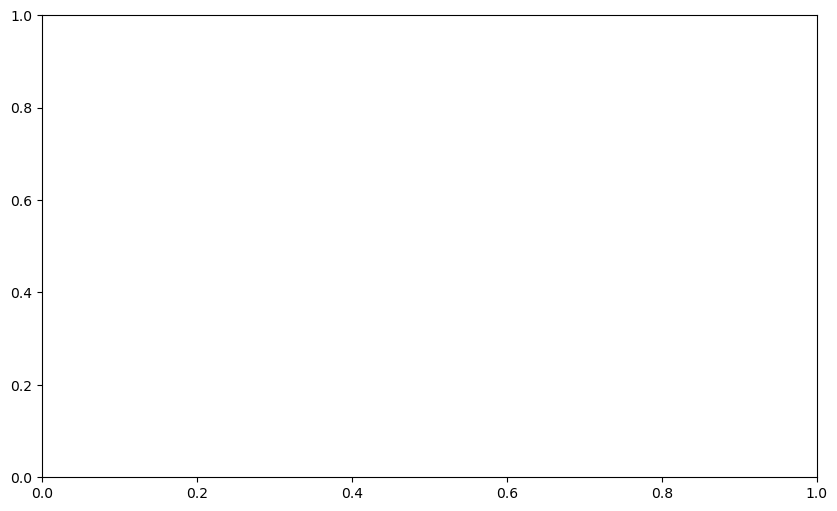

In [113]:
# Experiment: Wide Model
wide_model = BikeDemandNet(
    input_size=33, 
    hidden_layers=[512, 256, 128], 
    dropout_rate=0.2
)

print("\n>>> STARTING WIDE MODEL <<<")
wide_model, wide_train_loss, wide_val_loss = train_engine(
    wide_model, 
    train_full_loader, 
    val_loader, 
    epochs=30, 
    lr=0.001, 
    device=device
)

plot_losses(wide_train_loss, wide_val_loss, num_epochs=30)

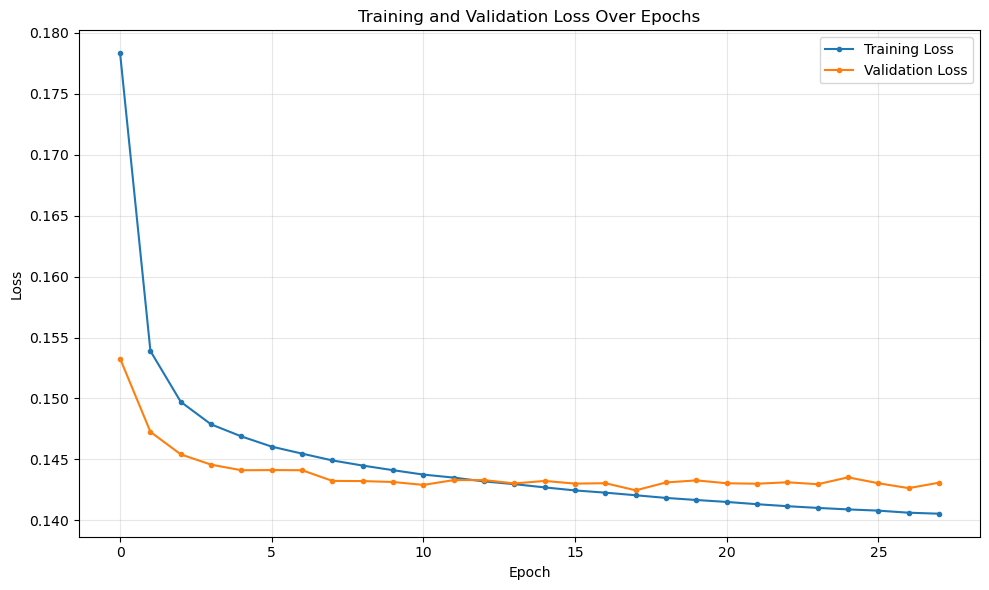

In [116]:
plot_losses(wide_train_loss, wide_val_loss, num_epochs=28)

### Final Test

In [118]:
model = wide_model

def evaluate_final_model(model, test_loader, device):
    model.eval() 
    all_preds_log = []
    all_labels_log = []
    
    # 1. Collect Log Predictions and Actuals
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            
            all_preds_log.extend(outputs.cpu().numpy().flatten())
            all_labels_log.extend(y_batch.cpu().numpy().flatten())
            
    # Convert lists to NumPy arrays
    preds_log = np.array(all_preds_log)
    labels_log = np.array(all_labels_log)
    
    # --- DIAGNOSTIC: CHECK NEGATIVE PREDICTIONS ---
    neg_count = (preds_log < 0).sum()
    total_count = len(preds_log)
    neg_pct = (neg_count / total_count) * 100
    
    # 2. Inverse Transform to Real Scale (Bikes)
    # The negative predictions are CLAMPED to 0 here for final metrics
    preds_real = np.maximum(np.expm1(preds_log), 0)
    labels_real = np.expm1(labels_log)

    # 3. Calculate Final Metrics (on Real Scale)
    final_rmse = np.sqrt(mean_squared_error(labels_real, preds_real))
    final_mae = mean_absolute_error(labels_real, preds_real)
    final_r2 = r2_score(labels_real, preds_real)
    
    # Return metrics and diagnostics
    return final_rmse, final_mae, final_r2, neg_count, neg_pct

# --- EXECUTION ---
final_rmse, final_mae, final_r2, neg_count, neg_pct = evaluate_final_model(model, test_loader, device)

print("\n" + "="*50)
print(f"FINAL TEST SET EVALUATION (Real Bike Counts)")
print("="*50)
print(f"Model: {model.__class__.__name__} (Best Tuned)")
print(f"R-squared (R²): {final_r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {final_rmse:.4f} bikes")
print(f"Mean Absolute Error (MAE): {final_mae:.4f} bikes")
print("-" * 50)
print(f"Negative Log Predictions: {neg_count} ({neg_pct:.2f}%)")
print("(Clamped to 0 for metric calculation)")
print("="*50)


FINAL TEST SET EVALUATION (Real Bike Counts)
Model: BikeDemandNet (Best Tuned)
R-squared (R²): 0.6050
Root Mean Squared Error (RMSE): 1.2551 bikes
Mean Absolute Error (MAE): 0.5643 bikes
--------------------------------------------------
Negative Log Predictions: 33957 (2.54%)
(Clamped to 0 for metric calculation)


### Visualizations

In [119]:
# --- A. HELPER TO GET PLOTTING DATA ---
def get_evaluation_arrays(model, test_loader, device):
    """Runs inference and returns real-scale predictions and actuals."""
    model.eval()
    all_preds_log = []
    all_labels_log = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            
            all_preds_log.extend(outputs.cpu().numpy().flatten())
            all_labels_log.extend(y_batch.cpu().numpy().flatten())
            
    preds_log = np.array(all_preds_log)
    labels_log = np.array(all_labels_log)
    
    # Inverse Transform
    preds_real = np.maximum(np.expm1(preds_log), 0)
    labels_real = np.expm1(labels_log)
    
    return preds_real, labels_real

# --- B. SIMPLIFIED PERMUTATION IMPORTANCE ---
def get_permutation_importance(model, X_df_scaled, labels_real, device, n_samples=10000):
    """
    Calculates feature importance by measuring the degradation of the score 
    when a feature is shuffled. Uses RMSE as the baseline score.
    """
    # Sample a small subset for quick calculation (10k rows)
    np.random.seed(42)
    sample_indices = np.random.choice(len(X_df_scaled), n_samples, replace=False)
    X_sample = X_df_scaled.iloc[sample_indices].copy()
    y_sample_real = labels_real[sample_indices]
    
    # Baseline Score (Score of the original model)
    X_tensor = torch.tensor(X_sample.values, dtype=torch.float32).to(device)
    with torch.no_grad():
        baseline_preds_log = model(X_tensor).cpu().numpy().flatten()
    baseline_preds_real = np.maximum(np.expm1(baseline_preds_log), 0)
    baseline_score = np.sqrt(mean_squared_error(y_sample_real, baseline_preds_real))
    
    importance_scores = {}
    
    # Iterate through features
    for col in X_sample.columns:
        X_shuffled = X_sample.copy()
        
        # 1. Shuffle the current feature column
        shuffled_values = X_shuffled[col].values.copy()
        np.random.shuffle(shuffled_values)
        X_shuffled[col] = shuffled_values
        
        # 2. Predict with the shuffled data
        X_shuffled_tensor = torch.tensor(X_shuffled.values, dtype=torch.float32).to(device)
        with torch.no_grad():
            shuffled_preds_log = model(X_shuffled_tensor).cpu().numpy().flatten()
        shuffled_preds_real = np.maximum(np.expm1(shuffled_preds_log), 0)
        
        # 3. Calculate degraded score (higher error = more important feature)
        degraded_score = np.sqrt(mean_squared_error(y_sample_real, shuffled_preds_real))
        
        # Importance is the difference in RMSE
        importance_scores[col] = degraded_score - baseline_score
        
    feat_df = pd.DataFrame(
        list(importance_scores.items()), 
        columns=['Feature', 'Importance']
    ).sort_values(by='Importance', ascending=False)
    
    return feat_df

# --- C. MAIN PLOTTING FUNCTION ---
def plot_nn_results(preds_real, labels_real, feature_importance_df, r2_score):
    residuals = labels_real - preds_real

    plt.figure(figsize=(20, 6))

    # --- PLOT A: Actual vs. Predicted (Scatter Plot) ---
    plt.subplot(1, 3, 1)
    plt.scatter(preds_real, labels_real, alpha=0.05, color='darkred', s=10) # Changed color
    
    max_val = max(labels_real.max(), preds_real.max())
    plt.plot([0, max_val], [0, max_val], '--', color='black', linewidth=2, label='Perfect Fit')

    plt.xlabel('Predicted Demand (Bikes)')
    plt.ylabel('Actual Demand (Bikes)')
    plt.title(f'NN Test Set: Actual vs. Predicted\n$R^2$: {r2_score:.4f}')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # --- PLOT B: Feature Importance (Permutation) ---
    plt.subplot(1, 3, 2)
    
    # Take top 15 features
    feat_df_top = feature_importance_df.head(15)

    sns.barplot(
        x='Importance', 
        y='Feature', 
        data=feat_df_top, 
        palette='rocket', 
        hue='Feature', 
        legend=False
    )
    plt.title('Top Drivers of Demand (Permutation)')
    plt.xlabel('Importance (Increase in RMSE)')

    # --- PLOT C: Residual Distribution (The "Bias" Chart) ---
    plt.subplot(1, 3, 3)
    p01 = np.percentile(residuals, 1)
    p99 = np.percentile(residuals, 99)
    clipped_residuals = residuals[(residuals > p01) & (residuals < p99)]

    sns.histplot(clipped_residuals, bins=50, kde=True, color='red')
    plt.axvline(0, color='black', linestyle='--', linewidth=2)
    plt.title(f'NN Error Distribution\n(Mean Error: {np.mean(residuals):.2f})')
    plt.xlabel('Residual (Actual - Predicted)')

    plt.tight_layout()
    plt.show()

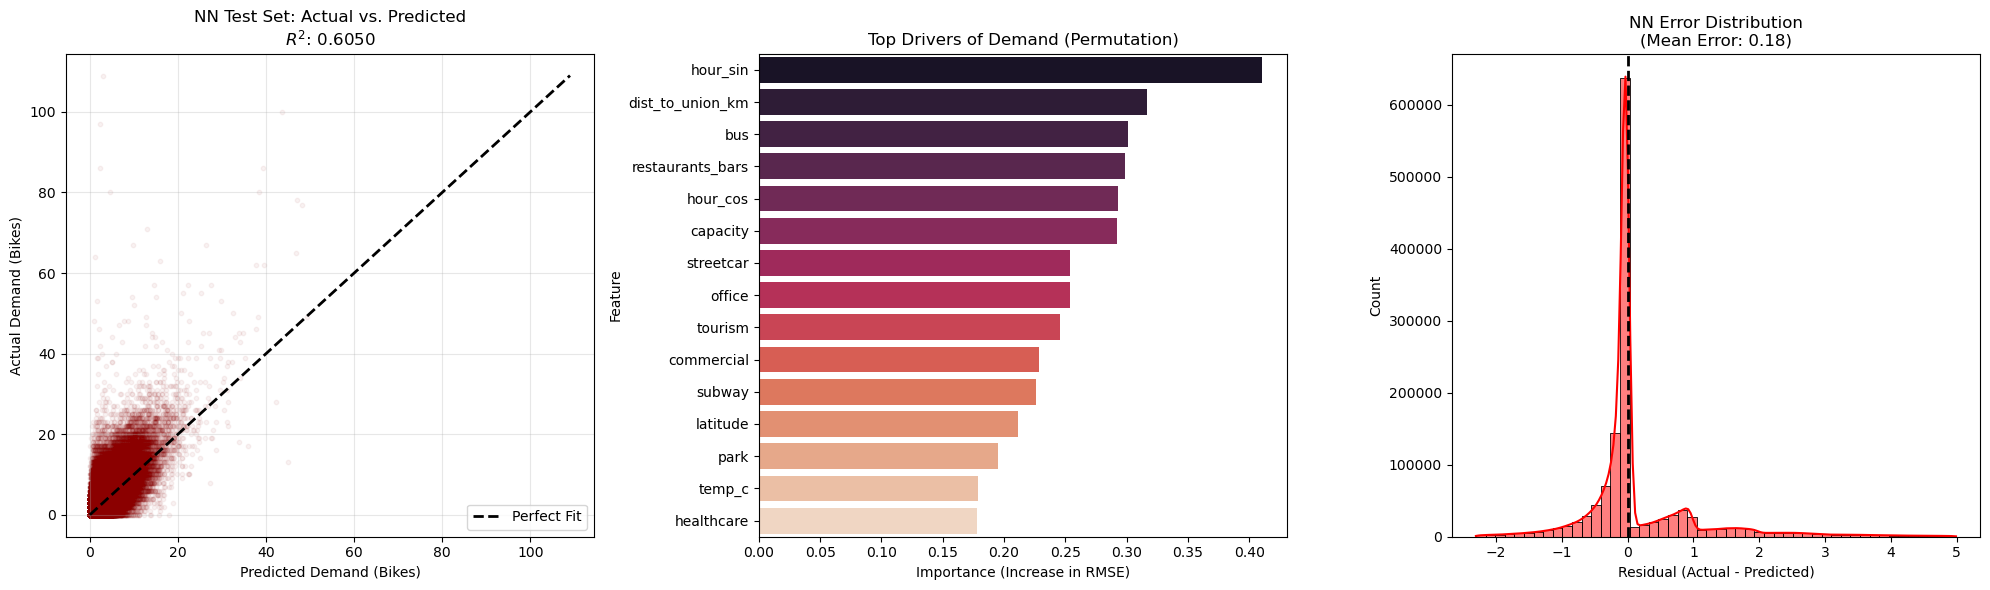

In [120]:
# Assuming X_test_nn_scaled is available and represents the features used by the NN model
# Assuming the final R2 score (final_r2) from your metric calculation is available

# 1. Retrieve the necessary arrays for plotting
preds_real, labels_real = get_evaluation_arrays(model, test_loader, device)

# 2. Calculate the Permutation Importance
# NOTE: This step is computationally intensive! Running on 10,000 samples 
# is a necessary trade-off for speed in a notebook environment.
importance_df = get_permutation_importance(
    model, 
    X_test_nn_scaled, 
    labels_real, 
    device, 
    n_samples=10000
)

# 3. Generate the Plots
plot_nn_results(preds_real, labels_real, importance_df, final_r2)